# IQR Method for Outlier Detection

The **Interquartile Range (IQR)** is a statistical method commonly used to detect outliers.

IQR measures the spread of the middle 50% of the data.

The IQR is calculated as:

IQR = Q3 - Q1

Where:

- Q1 = First Quartile (25th percentile)
- Q3 = Third Quartile (75th percentile)

An observation is commonly considered an outlier if it falls below the lower bound or above the upper bound.

In [1]:
import pandas as pd
import numpy as np

df = pd.DataFrame({
    "Salary": [
        30000, 32000, 35000, 36000, 38000,
        40000, 42000, 45000, 47000, 50000,
        200000
    ]
})

df

,Salary
0,30000
1,32000
2,35000
3,36000
4,38000
5,40000
6,42000
7,45000
8,47000
9,50000


#### Calculating Q1 and Q3

The first quartile (Q1) represents the 25th percentile.

The third quartile (Q3) represents the 75th percentile.

We can calculate them using Pandas.

In [2]:
Q1 = df["Salary"].quantile(0.25)
Q3 = df["Salary"].quantile(0.75)

print("Q1:", Q1)
print("Q3:", Q3)

Q1: 35500.0
Q3: 46000.0


#### Calculating the IQR

The Interquartile Range is:

**IQR = Q3 - Q1**

It represents the range containing the middle 50% of observations.

In [3]:
IQR = Q3 - Q1

print("IQR:", IQR)

IQR: 10500.0


#### Calculating Outlier Boundaries

The standard IQR method uses:

**Lower Bound = Q1 - 1.5 × IQR**

**Upper Bound = Q3 + 1.5 × IQR**

Values below the lower bound or above the upper bound are considered potential outliers.

In [4]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Lower Bound: 19750.0
Upper Bound: 61750.0


In [5]:
outliers = df[
    (df["Salary"] < lower_bound) |
    (df["Salary"] > upper_bound)
]

outliers

,Salary
10,200000


In [6]:
non_outliers = df[
    (df["Salary"] >= lower_bound) &
    (df["Salary"] <= upper_bound)
]

non_outliers

,Salary
0,30000
1,32000
2,35000
3,36000
4,38000
5,40000
6,42000
7,45000
8,47000
9,50000


#### Creating an Outlier Indicator

We can create a new column that identifies whether each observation is an outlier.

In [7]:
df["is_outlier"] = (
    (df["Salary"] < lower_bound) |
    (df["Salary"] > upper_bound)
)

df

,Salary,is_outlier
0,30000,False
1,32000,False
2,35000,False
3,36000,False
4,38000,False
5,40000,False
6,42000,False
7,45000,False
8,47000,False
9,50000,False


#### Visualizing IQR Outliers

A box plot provides a visual representation of the quartiles and potential outliers.

Points outside the whiskers are potential outliers according to the IQR rule.

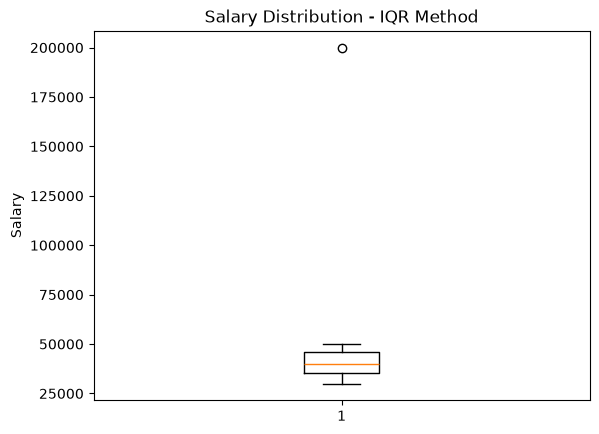

In [8]:
import matplotlib.pyplot as plt

plt.boxplot(df["Salary"])

plt.title("Salary Distribution - IQR Method")
plt.ylabel("Salary")

plt.show()

In [9]:
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = data[
        (data[column] < lower_bound) |
        (data[column] > upper_bound)
    ]
    
    return outliers

In [10]:
detect_outliers_iqr(df, "Salary")

,Salary,is_outlier
10,200000,True


In [11]:
numerical_columns = df.select_dtypes(
    include=np.number
).columns

for column in numerical_columns:
    
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = df[
        (df[column] < lower) |
        (df[column] > upper)
    ]
    
    print(f"{column}: {len(outliers)} outliers")

Salary: 1 outliers
